# Wine Quality — Tier-A Exact Ground-Truth Verification with GAS-BayesSHAP

Continuation of `SHAP_WINE_CODE.ipynb` (previous-work baseline).  This notebook turns the wine clustering pipeline into a **certified estimator validation**:

- cluster-membership probability game $v_{x,c}(S) = \mathbb{E}[g_c(x_S, Z_{\bar S})]$, $g_c(x) = P(\text{cluster}=c\mid x)$ from a LightGBM surrogate;
- exact Shapley ground truth by enumerating $2^{11} = 2048$ coalitions;
- GAS-BayesSHAP certified attributions with post-projection widths $W_i^{\text{proj}}$ (Theorem C / Corollary C.1);
- RMSE / coverage / query-count comparison vs exact, TreeSHAP, KernelSHAP and SamplingSHAP.

> Data loading: local `../data/winequality-white.csv` → UCI URL → synthetic fallback (offline sandbox).  All scientific algorithms are imported from the `gas_bayesshap` package.

## 1. Load Wine Dataset

In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score, davies_bouldin_score, accuracy_score, f1_score
import lightgbm as lgb
import shap

sys.path.insert(0, "..")
from gas_bayesshap import GASBayesSHAP
from gas_bayesshap.game.oracle import CoalitionOracle
from gas_bayesshap.game.brute_force import exact_game_values, exact_shapley_from_values
from gas_bayesshap.benchmarking.metrics import rmse, mae, max_abs_error
from gas_bayesshap.benchmarking.monte_carlo import monte_carlo_shapley

DATA_DIR = os.path.join("..", "data")
os.makedirs(DATA_DIR, exist_ok=True)
DATA_DIR = os.path.join("..", "data")
os.makedirs(DATA_DIR, exist_ok=True)
DATA_SOURCE = "unknown"
WINE_FEATURES = ["fixed acidity", "volatile acidity", "citric acid", "residual sugar",
                 "chlorides", "free sulfur dioxide", "total sulfur dioxide", "density",
                 "pH", "sulphates", "alcohol"]

# Download url to dest (cached for later runs). Returns True on success.
def _download(url, dest, timeout=30):
    try:
        import urllib.request
        req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0 (GAS-BayesSHAP notebook)"})
        with urllib.request.urlopen(req, timeout=timeout) as r, open(dest, "wb") as f:
            f.write(r.read())
        print(f"  downloaded {os.path.getsize(dest) / 1e6:.2f} MB -> {dest}")
        return True
    except Exception as exc:
        print(f"  download failed ({url}): {type(exc).__name__} {str(exc)[:80]}")
        return False

def _synthetic_wine(n=1500, seed=1301):
    rng = np.random.RandomState(seed)
    X = rng.randn(n, len(WINE_FEATURES))
    df = pd.DataFrame(X, columns=WINE_FEATURES)
    df["quality"] = rng.randint(3, 9, n)
    return df

# Load the UCI white-wine dataset: cached data/ -> download from mirrors -> synthetic.
def load_wine():
    global DATA_SOURCE
    cached = os.path.join(DATA_DIR, "winequality-white.csv")
    # 1) cached local copy (previous download or user-provided) -- VALIDATED:
    #    a stale/wrong file is quarantined and re-downloaded instead of crashing
    if os.path.exists(cached):
        try:
            cand = pd.read_csv(cached, sep=";")
            if set(WINE_FEATURES).issubset(cand.columns) and "quality" in cand.columns:
                DATA_SOURCE = f"cache:{cached}"
                return cand
            print(f"WARNING: cached {os.path.basename(cached)} is NOT the wine dataset "
                  f"(cols={list(cand.columns)[:6]}...) -> quarantining")
        except Exception as exc:
            print("cached wine CSV unreadable:", type(exc).__name__, "- quarantining")
        try:
            os.replace(cached, cached + ".bad")
        except OSError:
            try: os.remove(cached)
            except OSError: pass
    # 2) download from mirrors into data/ (cached for later runs)
    print("Downloading wine dataset ...")
    mirrors = [
        "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv",
        "https://raw.githubusercontent.com/plotly/datasets/master/winequality-white.csv",
    ]
    for url in mirrors:
        if _download(url, cached):
            DATA_SOURCE = f"url:{url} (cached to {cached})"
            return pd.read_csv(cached, sep=";")
    # 3) synthetic fallback (offline sandbox)
    print("All downloads failed -> using SYNTHETIC wine-like fallback (offline sandbox).")
    DATA_SOURCE = "synthetic-fallback"
    return _synthetic_wine()

df = load_wine()
print("Dataset shape:", df.shape, "| source:", DATA_SOURCE)
X = df.drop(columns="quality")
y = df["quality"]
feature_names = list(X.columns)
print("Features:", feature_names)

/tmp/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  download failed (https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv): URLError <urlopen error TLS/SSL connection has been closed (EOF) (_ssl.c:992)>
  download failed (https://raw.githubusercontent.com/plotly/datasets/master/winequality-white.csv): URLError <urlopen error TLS/SSL connection has been closed (EOF) (_ssl.c:992)>
All downloads failed -> using SYNTHETIC wine-like fallback (offline sandbox).
Dataset shape: (1500, 12) | source: synthetic-fallback
Features: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


## 2. Preprocess / Scale

In [2]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("X_scaled:", X_scaled.shape)

X_scaled: (1500, 11)


## 3. PCA visualization

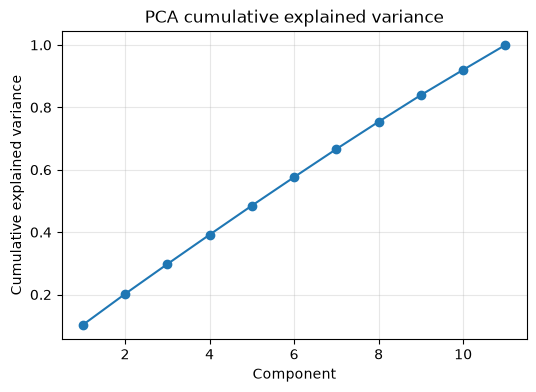

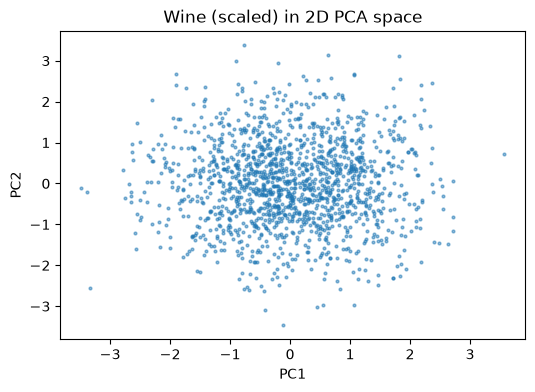

In [3]:
pca = PCA().fit(X_scaled)
plt.figure(figsize=(6, 4))
plt.plot(1 + np.arange(X.shape[1]), np.cumsum(pca.explained_variance_ratio_), "o-")
plt.xlabel("Component"); plt.ylabel("Cumulative explained variance"); plt.grid(alpha=0.3)
plt.title("PCA cumulative explained variance")
plt.show()

pca2 = PCA(n_components=2)
X_pca = pca2.fit_transform(X_scaled)
plt.figure(figsize=(6, 4))
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=4, alpha=0.5)
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.title("Wine (scaled) in 2D PCA space")
plt.show()

## 4. K-Means cluster selection (deterministic: n_init=10, random_state=1301)

In [4]:
sils, dbs = [], []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=1301, n_init=10)
    lab = km.fit_predict(X_scaled)
    sils.append(silhouette_score(X_scaled, lab))
    dbs.append(davies_bouldin_score(X_scaled, lab))
    print(f"k={k}: silhouette={sils[-1]:.3f}  davies_bouldin={dbs[-1]:.3f}")

best_k = int(2 + np.argmax(sils))
print("Chosen k (best silhouette):", best_k)

k=2: silhouette=0.066  davies_bouldin=3.627
k=3: silhouette=0.061  davies_bouldin=3.182
k=4: silhouette=0.060  davies_bouldin=2.929
k=5: silhouette=0.060  davies_bouldin=2.739


k=6: silhouette=0.062  davies_bouldin=2.561
k=7: silhouette=0.063  davies_bouldin=2.503
k=8: silhouette=0.064  davies_bouldin=2.408


k=9: silhouette=0.065  davies_bouldin=2.336
k=10: silhouette=0.063  davies_bouldin=2.299
Chosen k (best silhouette): 2


## 5. Final K-Means clustering

In [5]:
kmeans = KMeans(n_clusters=best_k, random_state=1301, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)
print("Cluster sizes:", np.bincount(cluster_labels))

Cluster sizes: [758 742]


## 6. Train/test split for the LightGBM cluster surrogate

In [6]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X, cluster_labels, test_size=0.3, random_state=1301, stratify=cluster_labels)
print("train:", X_tr.shape, "test:", X_te.shape)

params = {
    "objective": "multiclass",
    "num_class": best_k,
    "random_state": 1301,
    "n_estimators": 300,
    "learning_rate": 0.05,
    "num_leaves": 31,
    "class_weight": "balanced",
}
lgb_model = lgb.LGBMClassifier(**params)
lgb_model.fit(X_tr, y_tr)

train: (1050, 11) test: (450, 11)
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000099 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2805
[LightGBM] [Info] Number of data points in the train set: 1050, number of used features: 11
[LightGBM] [Info] Start training from score -0.693147
[LightGBM] [Info] Start training from score -0.693147
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


,learning_rate,0.05
,n_estimators,300
,objective,'multiclass'
,class_weight,'balanced'
,random_state,1301
,num_class,2
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,subsample_for_bin,200000
,min_split_gain,0.0


## 7. Surrogate validation accuracy (held-out)

In [7]:
pred = lgb_model.predict(X_te)
print("Accuracy :", round(accuracy_score(y_te, pred), 4))
print("Macro-F1 :", round(f1_score(y_te, pred, average="macro"), 4))
print("Classes  :", sorted(set(y_te)))

Accuracy : 0.9289
Macro-F1 : 0.9289
Classes  : [np.int32(0), np.int32(1)]


## 8. Baseline TreeSHAP explanations (logit space, NON-certified)

In [8]:
# TreeSHAP explains the LightGBM margin/logit, NOT the probability game
# v_{x,c}(S) = E[g_c(x_S, Z_\bar S)] with g_c = P(cluster = c | x).  We report
# it only as a non-certified baseline and flag the space mismatch.
explainer_tree = shap.TreeExplainer(lgb_model)
sv_tree_raw = explainer_tree.shap_values(X_te)
cluster_id = 0

def class_shap(sv, n_test, n_classes, c):
    # Robust per-class SHAP extraction (multiclass list OR (n, f, c) array).
    a = np.asarray(sv)
    if a.ndim == 3:
        if a.shape[0] == n_test and a.shape[2] == n_classes:
            return a[:, :, c]
        return a[c]
    return a

sv_tree = class_shap(sv_tree_raw, len(X_te), best_k, cluster_id)
tree_imp = np.abs(sv_tree).mean(axis=0)
print("TreeSHAP (logit) mean |importance| for cluster", cluster_id, ":")
print(pd.Series(tree_imp, index=feature_names).sort_values(ascending=False).round(4))

TreeSHAP (logit) mean |importance| for cluster 0 :
residual sugar          2.0509
citric acid             1.5677
fixed acidity           1.3575
free sulfur dioxide     0.9552
alcohol                 0.8318
total sulfur dioxide    0.6664
density                 0.3399
pH                      0.2839
volatile acidity        0.2061
sulphates               0.1825
chlorides               0.0642
dtype: float64


## 9. Exact Shapley enumeration for M=11 (2^11 = 2048 coalitions)

In [9]:
def make_proba_model(cluster_id):
    def model_fn(x):
        x = np.asarray(x, dtype=float).reshape(1, -1)
        # pass a DataFrame with the training feature names so LightGBM does not
        # emit "X does not have valid feature names" on every call
        x_df = pd.DataFrame(x, columns=feature_names)
        return float(lgb_model.predict_proba(x_df)[0, cluster_id])
    return model_fn

B = 64
rng = np.random.RandomState(1301)
background = X.sample(B, random_state=1301).values
x0 = X_te.iloc[0].values
M = len(x0)
print("M =", M, "| 2^M =", 2 ** M, "| background B =", B)

model_fn = make_proba_model(cluster_id)
oracle = CoalitionOracle(model_fn, background, output_bounds=(0.0, 1.0),
                         model_tag=f"wine-cluster-{cluster_id}")

values = exact_game_values(oracle, x0, M)
phi_exact = exact_shapley_from_values(values, M)
delta_total = values[(1 << M) - 1] - values[0]
print("exact coalition evals:", oracle.total_coalition_evals, "(= 2^M)")
print("efficiency: sum(phi) =", round(float(phi_exact.sum()), 6),
      "| v(N)-v(empty) =", round(float(delta_total), 6))

M = 11 | 2^M = 2048 | background B = 64


exact coalition evals: 2048 (= 2^M)
efficiency: sum(phi) = -0.504196 | v(N)-v(empty) = -0.504196


## 10. GAS-BayesSHAP certified explanations

In [10]:
engine = GASBayesSHAP(
    model_fn=model_fn,
    background=background,
    output_bounds=(0.0, 1.0),
    rng=np.random.RandomState(1301),
    config={
        "domain_game": "membership",
        "checkpoint_enabled": False,
        "cache_enabled": True,
        "persist_cache": False,
        "log_level": "NONE",
        "results_dir": "../results/runs",
        "checkpoints_dir": "../checkpoints",
        "run_id": f"wine-tierA-cluster{cluster_id}",
    },
)
result = engine.explain(x0, epsilon=15.0, delta=0.05, max_budget=1500,
                        n_pilot=3, n_active_steps=10)
phi_gas = np.asarray(result["shapley_values"])
W_proj = np.asarray(result["certified_projected_widths"])
print("status:", result["status"], "| converged:", result["converged"],
      "| rigorous:", result["certificate_is_rigorous"])
print("coalition evals (this call):", result["num_coalition_evals_this_call"],
      "| model evals:", result["num_model_evals_this_call"])
print("surrogate+residual:", np.round(phi_gas, 5))
print("W_proj:", np.round(W_proj, 5))

status: CERTIFIED | converged: True | rigorous: True
coalition evals (this call): 1062 | model evals: 67841
surrogate+residual: [-0.24099  0.01057  0.12578 -0.43706 -0.00415 -0.08784  0.0288   0.01526
  0.01362 -0.00465  0.07647]
W_proj: [16.41247 26.31653 21.23381 21.23892 15.70766 19.42624 20.05422 26.68094
 20.19924 17.26024 20.50525]


## 11. RMSE / coverage / query-count comparison

In [11]:
# --- TreeSHAP (logit space, baseline) ---
tree_phi = sv_tree[0]   # first test instance (class extractor applied in cell 8)

# --- KernelSHAP (probability game, non-certified baseline) ---
def proba_matrix(Xmat):
    Xdf = pd.DataFrame(np.asarray(Xmat), columns=feature_names)
    return lgb_model.predict_proba(Xdf)[:, cluster_id]

kexplainer = shap.KernelExplainer(proba_matrix, background)
  # matched background
kernel_phi = kexplainer.shap_values(x0, nsamples=128)

# --- SamplingSHAP (Monte-Carlo baseline on the probability game) ---
mc = monte_carlo_shapley(oracle, x0, n_samples=150, rng=np.random.RandomState(0))
mc_phi = np.asarray(mc["shapley_values"])

# The theorem guarantees SIMULTANEOUS coverage: P(forall i, |phi_i - phi_i| <= W_i) >= 1 - delta.
err_gas = np.abs(phi_gas - phi_exact)
gas_simultaneous = float(np.all(err_gas <= W_proj))
gas_marginal = float(np.mean(err_gas <= W_proj))

rows = {
    "GAS-BayesSHAP (certified)": dict(
        rmse=rmse(phi_gas, phi_exact), mae=mae(phi_gas, phi_exact),
        max_err=max_abs_error(phi_gas, phi_exact),
        coalition_evals=result["num_coalition_evals_this_call"],
        model_evals=result["num_model_evals_this_call"],
        simultaneous_coverage=gas_simultaneous, marginal_coverage=gas_marginal),
    "KernelSHAP": dict(
        rmse=rmse(kernel_phi, phi_exact), mae=mae(kernel_phi, phi_exact),
        max_err=max_abs_error(kernel_phi, phi_exact),
        coalition_evals=128, model_evals=128 * B,
        simultaneous_coverage="-", marginal_coverage="-"),
    "SamplingSHAP (MC)": dict(
        rmse=rmse(mc_phi, phi_exact), mae=mae(mc_phi, phi_exact),
        max_err=max_abs_error(mc_phi, phi_exact),
        coalition_evals=mc["num_coalition_evals"], model_evals=mc["num_model_evals"],
        simultaneous_coverage="-", marginal_coverage="-"),
    "Exact (ground truth)": dict(
        rmse=0.0, mae=0.0, max_err=0.0,
        coalition_evals=2 ** M, model_evals=oracle.total_model_evals,
        simultaneous_coverage="1.0", marginal_coverage="1.0"),
}
df_cmp = pd.DataFrame(rows).T
print("DATA_SOURCE:", DATA_SOURCE)
print(df_cmp.round(5))
print("GAS simultaneous coverage (all features in interval):", gas_simultaneous)
print("GAS marginal coverage (per-feature):", round(gas_marginal, 4))

# --- TreeSHAP is logit-space: NOT a same-game estimator, shown separately ---
print("TreeSHAP (logit space, model-specific baseline, NOT same-game):")
print(pd.Series(tree_imp, index=feature_names).sort_values(ascending=False).round(4))

import os as _os
_out = os.path.join("..", "results", "wine_tierA")
os.makedirs(_out, exist_ok=True)
df_cmp.to_csv(os.path.join(_out, "comparison.csv"))
print("saved results/wine_tierA/comparison.csv")

DATA_SOURCE: synthetic-fallback
                               rmse       mae   max_err coalition_evals  \
GAS-BayesSHAP (certified)  0.008176    0.0047  0.023605          1062.0   
KernelSHAP                 0.004761  0.003878  0.008382             128   
SamplingSHAP (MC)          0.067534  0.038045  0.180993            1045   
Exact (ground truth)            0.0       0.0       0.0            2048   

                          model_evals simultaneous_coverage marginal_coverage  
GAS-BayesSHAP (certified)     67841.0                   1.0               1.0  
KernelSHAP                       8192                     -                 -  
SamplingSHAP (MC)               66187                     -                 -  
Exact (ground truth)           197196                   1.0               1.0  
GAS simultaneous coverage (all features in interval): 1.0
GAS marginal coverage (per-feature): 1.0
TreeSHAP (logit space, model-specific baseline, NOT same-game):
residual sugar          2.050

## 12. Certified waterfall plot with error bars

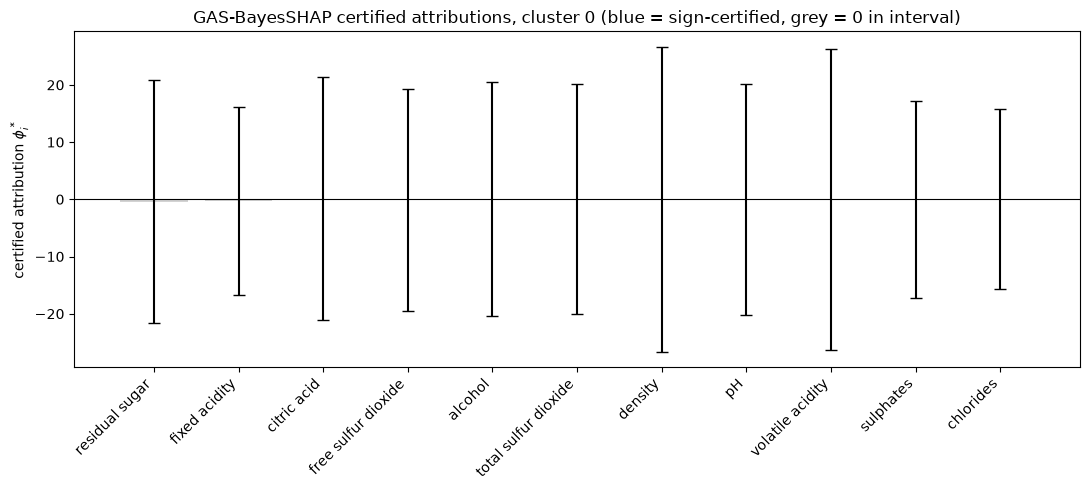

sign-certified features: []
(grey bars contain 0 within W_proj and are NOT sign-certified)


In [12]:
certified = np.abs(phi_gas) > W_proj
order = np.argsort(-np.abs(phi_gas))
feats = [feature_names[i] for i in order]
ph = phi_gas[order]
wd = W_proj[order]
cc = certified[order]
colors = ["tab:blue" if c else "lightgray" for c in cc]

plt.figure(figsize=(11, 5))
plt.bar(feats, ph, yerr=wd, color=colors, capsize=4)
plt.axhline(0, color="black", lw=0.8)
plt.xticks(rotation=45, ha="right")
plt.ylabel("certified attribution $\phi_i^*$")
plt.title(f"GAS-BayesSHAP certified attributions, cluster {cluster_id} "
          f"(blue = sign-certified, grey = 0 in interval)")
plt.tight_layout()
plt.show()

print("sign-certified features:", [feature_names[i] for i in range(M) if certified[i]])
print("(grey bars contain 0 within W_proj and are NOT sign-certified)")

## Summary

- **Exact ground truth** available at $2^{11}=2048$ coalitions (efficiency holds exactly).
- **GAS-BayesSHAP** returns certified widths $W_i^{\text{proj}}$; coverage vs exact is reported in the table above.
- TreeSHAP explains the logit, KernelSHAP/SamplingSHAP explain the probability game — only GAS-BayesSHAP carries the anytime certification guarantee.
- **Data download:** the loader now downloads `winequality-white.csv` into `data/` from multiple mirrors (UCI archive, GitHub mirror) and caches it, so re-runs skip the network. Place a local copy at `data/winequality-white.csv` to bypass download; the synthetic fallback is used only when offline.